# Задание Lite

Создайте нейронную сеть, распознающую рукописные цифры. Используя подготовленную базу и шаблон ноутбука, нормируйте данные, создайте и обучите сверточную сеть.

**Параметры модели:** сеть должна содержать минимум 2 сверточных слоя; полносвязные слои; слои подвыборки, нормализации, регуляризации по 1 шт.

**Гиперпараметры обучения:** функция ошибки - категориальная кроссэнтропия, оптимизатор - Adam с шагом обучения одна тысячная, размер батча - 128, количество эпох 15, детали обучения - отображать.

**В конце** выведите график обучения: доли верных ответов на обучающей и проверочной выборках.

In [1]:


import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files

from tensorflow.keras import utils
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, Dropout, Dense, Flatten
from tensorflow.keras.optimizers import Adam

%matplotlib inline


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


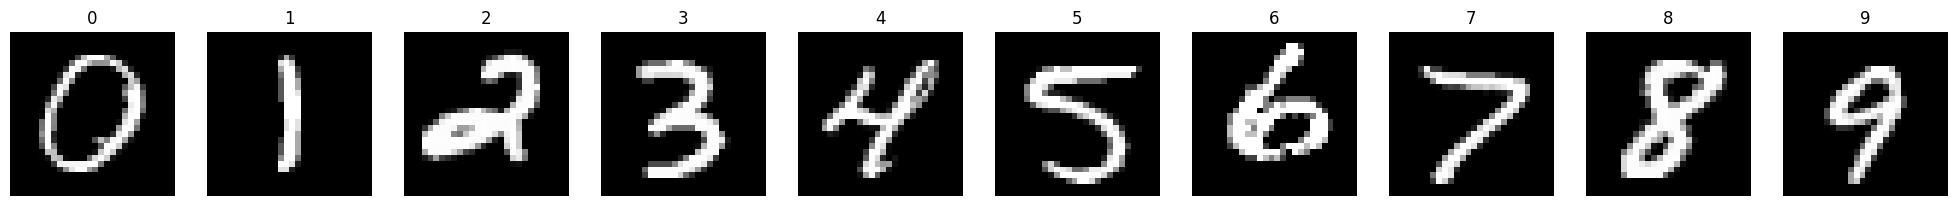

x_train: (60000, 28, 28, 1)
x_test: (10000, 28, 28, 1)
y_train: (60000, 10)
y_test: (10000, 10)


In [2]:

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Вывод
fig, axs = plt.subplots(1, 10, figsize=(25, 3))

for digit in range(10):
    digit_indexes = np.where(y_train == digit)[0]
    sample_index = random.choice(digit_indexes)
    sample_img = x_train[sample_index]

    axs[digit].imshow(sample_img, cmap='gray')
    axs[digit].set_title(str(digit))
    axs[digit].axis('off')

plt.show()


x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Нормировка значений пикселей в диапазон от 0 до 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Преобразуем ответы в категориальный вид
num_classes = 10
y_train = utils.to_categorical(y_train, num_classes)
y_test = utils.to_categorical(y_test, num_classes)

print('x_train:', x_train.shape)
print('x_test:', x_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)


In [3]:
class RecogNum:
    def __init__(self, epochs=15, batch_size=128):
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = None       # здесь будет храниться модель
        self.history = None     # здесь будет храниться история обучения

    # создание сверточной модели
    def create_model(self):
        model = Sequential([
            Input(shape=(28, 28, 1)),

            # первый сверточный блок
            Conv2D(32, (3, 3), padding='same', activation='relu'),
            BatchNormalization(),
            Dropout(0.4),

            # второй сверточный блок
            Conv2D(64, (3, 3), padding='same', activation='relu'),
            MaxPooling2D(pool_size=(2, 2)),

            # переход к полносвязным слоям
            Flatten(),
            Dense(128, activation='relu'),
            Dropout(0.3),

            # выходной слой на 10 цифр
            Dense(10, activation='softmax')
        ])

        model.compile(
            loss='categorical_crossentropy',
            optimizer=Adam(learning_rate=0.001),
            metrics=['accuracy']
        )

        return model

    # обучение модели
    def train_model(self):
        self.model = self.create_model()

        self.history = self.model.fit(
            x_train,
            y_train,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=1,
            shuffle=True,
            validation_data=(x_test, y_test)
        )

        test_loss, test_accuracy = self.model.evaluate(x_test, y_test, verbose=0)
        print(f'Ошибка на проверочной выборке: {test_loss:.4f}')
        print(f'Точность на проверочной выборке: {test_accuracy:.4f}')

        # сохранение обученной модели
        self.model.save('recog_num_model.keras')

        return self.history, test_loss, test_accuracy

    # загрузка изображения пользователя
    def upload_pic(self):
        uploaded = files.upload()

        if len(uploaded) == 0:
            raise ValueError('Файл не был загружен')

        filename = list(uploaded.keys())[0]
        print('Загружен файл:', filename)

        # открываем изображение в оттенках серого
        img = Image.open(filename).convert('L')
        img_array = np.array(img)

        plt.figure(figsize=(4, 4))
        plt.imshow(img_array, cmap='gray')
        plt.title('Исходное изображение')
        plt.axis('off')
        plt.show()

        # определяем яркость фона по краям изображения
        border_pixels = np.concatenate([
            img_array[0, :],
            img_array[-1, :],
            img_array[:, 0],
            img_array[:, -1]
        ])


        if border_pixels.mean() > 127:
            img_array = 255 - img_array

        # убираем слабый шум
        img_array[img_array < 20] = 0

        # находим область, где находится цифра
        coords = np.argwhere(img_array > 20)
        if len(coords) == 0:
            raise ValueError('Цифра на изображении не найдена')

        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)

        # обрезаем пустые поля вокруг цифры
        img_array = img_array[y_min:y_max + 1, x_min:x_max + 1]

        # помещаем цифру в квадрат с небольшим отступом
        h, w = img_array.shape
        canvas_size = max(h, w) + 12
        canvas = np.zeros((canvas_size, canvas_size), dtype=np.uint8)

        y_offset = (canvas_size - h) // 2
        x_offset = (canvas_size - w) // 2
        canvas[y_offset:y_offset + h, x_offset:x_offset + w] = img_array

        # приводим изображение к формату MNIST 28x28
        try:
            resize_filter = Image.Resampling.LANCZOS
        except AttributeError:
            resize_filter = Image.LANCZOS

        img_final = Image.fromarray(canvas).resize((28, 28), resize_filter)
        img_final = np.array(img_final).astype('float32') / 255.0

        plt.figure(figsize=(4, 4))
        plt.imshow(img_final, cmap='gray', interpolation='nearest')
        plt.title('Изображение для нейросети')
        plt.axis('off')
        plt.show()

        img_vector = img_final.reshape(1, 28, 28, 1)
        print('Форма для подачи в сеть:', img_vector.shape)

        return img_vector

    # распознавание цифры
    def predict_num(self):
        num_img = self.upload_pic()

        if self.model is None:
            self.model = load_model('recog_num_model.keras')

        prediction = self.model.predict(num_img, verbose=0)
        predicted_digit = int(np.argmax(prediction))

        print('Распознанная цифра:', predicted_digit)
        print('Вероятности по классам:')

        for digit, probability in enumerate(prediction[0]):
            print(f'{digit}: {probability:.6f}')

        return predicted_digit

    # график обучения
    def show_graph(self):
        if self.history is None:
            raise ValueError('История обучения отсутствует. Сначала выполните train_model().')

        plt.figure(figsize=(8, 5))

        plt.plot(self.history.history['accuracy'], label='Обучающая выборка')
        plt.plot(self.history.history['val_accuracy'], label='Проверочная выборка')

        plt.title('График точности обучения')
        plt.xlabel('Эпоха')
        plt.ylabel('Доля верных ответов')
        plt.legend()
        plt.grid(True)
        plt.show()


In [4]:
model = RecogNum(epochs=15, batch_size=128)
history, loss, accuracy = model.train_model()


Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 214s 452ms/step - accuracy: 0.8367 - loss: 0.5276 - val_accuracy: 0.9722 - val_loss: 0.2744
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 205s 437ms/step - accuracy: 0.9367 - loss: 0.2009 - val_accuracy: 0.9834 - val_loss: 0.0542
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 206s 438ms/step - accuracy: 0.9579 - loss: 0.1352 - val_accuracy: 0.9860 - val_loss: 0.0451
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 201s 429ms/step - accuracy: 0.9643 - loss: 0.1146 - val_accuracy: 0.9873 - val_loss: 0.0425
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 205s 438ms/step - accuracy: 0.9693 - loss: 0.0964 - val_accuracy: 0.9873 - val_loss: 0.0402
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 264s 443ms/step - accuracy: 0.9727 - loss: 0.0850 - val_accuracy: 0.9880 - val_loss: 0.0391
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 265s 449ms/step - accuracy: 0.9766 - loss: 0.0723 - val_accuracy: 0.9884 - val_loss: 0.0379
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 205s 438ms/step - accuracy: 0.9792 -

Saving 2.png to 2.png
Загружен файл: 2.png


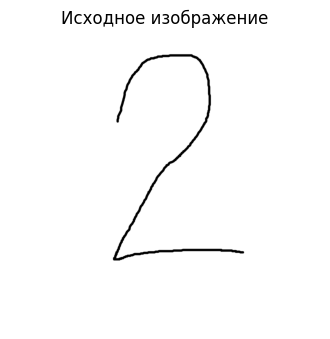

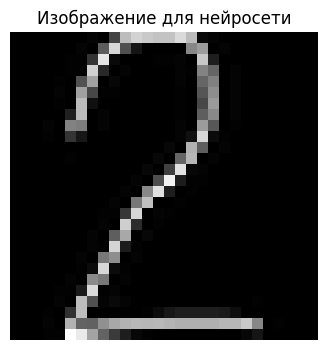

Форма для подачи в сеть: (1, 28, 28, 1)
Распознанная цифра: 2
Вероятности по классам:
0: 0.000648
1: 0.178739
2: 0.493730
3: 0.012244
4: 0.000059
5: 0.000025
6: 0.000979
7: 0.312759
8: 0.000064
9: 0.000753
Ответ модели: 2


In [5]:
predicted_digit = model.predict_num()
print('Ответ модели:', predicted_digit)


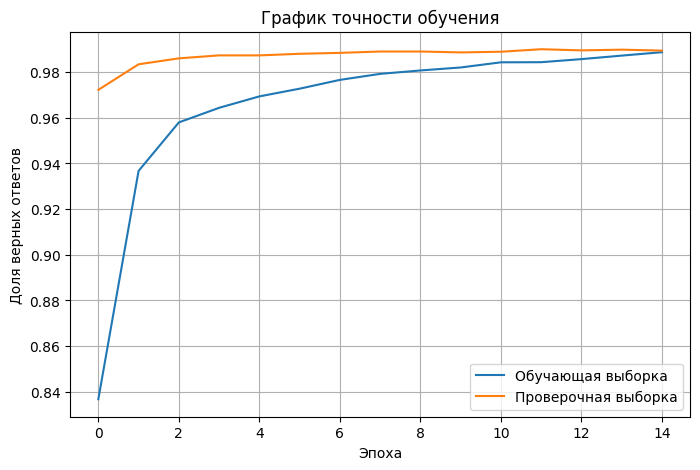

In [6]:
model.show_graph()
